In [ ]:
import StableDiffusion.ModelConverter
from StableDiffusion.DiffusionProcess import DiffusionProcess
device = 'cuda'
idleDevice = 'cpu'
filePath='../models/sd15models/v1-5-pruned-emaonly.ckpt'
diffusionDict = StableDiffusion.ModelConverter.load_from_standard_weights(input_file=filePath,\
                                                            device = 'cuda')
clipWeights=diffusionDict['clip']
diffusionWeights = diffusionDict['diffusion']
vaeEncoderWeights = diffusionDict['encoder']
vaeDecoderWeights = diffusionDict['decoder']

import torch
import StableDiffusion.ControlnetModelConverter
import importlib
importlib.reload(StableDiffusion.ControlnetModelConverter)
from StableDiffusion.ControlnetModelConverter import ControlnetModelConverter
filePath ="../models/ControlNet-v1-1/control_v11p_sd15_canny.pth" 
controlnetCannyDict  = torch.load(filePath, map_location= device)

import torch 
import StableDiffusion.VaeEncoder 
import StableDiffusion.VaeDecoder
import StableDiffusion.ClipEncoder
import StableDiffusion.DiffusionProcess
import importlib
importlib.reload(StableDiffusion.VaeEncoder)
importlib.reload(StableDiffusion.VaeDecoder)
importlib.reload(StableDiffusion.ClipEncoder)
importlib.reload(StableDiffusion.DiffusionProcess)
from StableDiffusion.VaeDecoder import VaeDecoder
from StableDiffusion.VaeEncoder import VaeEncoder
from StableDiffusion.ClipEncoder import ClipEncoder
from StableDiffusion.DiffusionProcess import DiffusionProcess
clipEncoder = ClipEncoder().to(device)
vaeEncoder = VaeEncoder().to(device)
vaeDecoder = VaeDecoder().to(device)
diffusionProcess = DiffusionProcess().to(device)
clipEncoder.load_state_dict(clipWeights,strict=True)
vaeEncoder.load_state_dict(vaeEncoderWeights ,strict=True)
vaeDecoder.load_state_dict(vaeDecoderWeights,strict=True)
diffusionProcess.load_state_dict(diffusionWeights,strict=True)



import StableDiffusion.ControlnetSD
import StableDiffusion.DiffusionProcessControlnet
importlib.reload(StableDiffusion.ControlnetSD)
importlib.reload(StableDiffusion.DiffusionProcessControlnet)
from StableDiffusion.ControlnetSD import ControlnetSD
from StableDiffusion.DiffusionProcessControlnet import DiffusionProcessControlnet


diffusionProcessControlnet = DiffusionProcessControlnet().to(device)
diffusionProcessControlnet.load_state_dict(diffusionWeights,strict=False)
#diffusionProcessControlnet.loadControlnetWeightsDict(controlWeightsDict =controlnetCannyDict)
diffusionProcessControlnet.loadControlnetWeightsDict(controlWeightsDict=None)

# test trained controlnet model

In [ ]:
import torch
import StableDiffusion.ControlnetModelConverter
import importlib
importlib.reload(StableDiffusion.ControlnetModelConverter)
from StableDiffusion.ControlnetModelConverter import ControlnetModelConverter
filePath ="/home/aistudio/models/training/controlnetCanny.ckpt" 
controlnetCannyDictTrained  = torch.load(filePath, map_location= device)
diffusionProcessControlnet.loadControlnetWeightsDict(controlWeightsDict =controlnetCannyDictTrained)


import os
import cv2
import wandb
import torch
import numpy as np
import matplotlib.pyplot as plt 
import importlib
from tqdm import tqdm
from IPython import display
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# --- 1. Local StableDiffusion Module Imports ---
import StableDiffusion.Utils
import StableDiffusion.DdpmSamplerTorch
import StableDiffusion.LoraDataSet
import StableDiffusion.ControlnetDataSet
import StableDiffusion.LoraUtils
import StableDiffusion.ControlnetUtils
import StableDiffusion.GenPipe
import StableDiffusion.GenPipeControlnet
import StableDiffusion.CannyEdgeDetection
import StableDiffusion.VaeEncoder
import StableDiffusion.ControlnetFill50kDataSet

# --- 2. Centralized Reload Logic ---
# Add any module here that you are actively editing
modulesToReload = [
    StableDiffusion.Utils, StableDiffusion.DdpmSamplerTorch, 
    StableDiffusion.LoraDataSet, StableDiffusion.ControlnetDataSet,
    StableDiffusion.LoraUtils, StableDiffusion.ControlnetUtils,
    StableDiffusion.GenPipe, StableDiffusion.GenPipeControlnet,
    StableDiffusion.CannyEdgeDetection, StableDiffusion.VaeEncoder,
    StableDiffusion.ControlnetFill50kDataSet,
]
for module in modulesToReload:
    importlib.reload(module)

# --- 3. Explicit Class/Function Imports ---
from StableDiffusion.Utils import Utils
from StableDiffusion.DdpmSamplerTorch import DdpmSamplerTorch
from StableDiffusion.LoraDataSet import LoraDataSet
from StableDiffusion.ControlnetDataSet import ControlnetDataSet
from StableDiffusion.LoraUtils import *
from StableDiffusion.ControlnetUtils import ControlnetUtils
from StableDiffusion.GenPipe import GenPipe
from StableDiffusion.GenPipeControlnet import GenPipeControlnet
from StableDiffusion.CannyEdgeDetection import CannyEdgeDetection
from StableDiffusion.CannyToLatent import CannyToLatent
from StableDiffusion.ControlnetTimeEmbedding import ControlnetTimeEmbedding
from StableDiffusion.ZeroConvLayer import ZeroConvLayer
from StableDiffusion.VaeEncoder import VaeEncoder
from StableDiffusion.ControlnetFill50kDataSet import ControlnetFill50kDataSet
filePath = './images/pusiyue_rose_1024_1024.jpg'
img = cv2.imread(filePath)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (512, 512))
cannyDetector = CannyEdgeDetection()
edgeImg = cannyDetector(img)
print(edgeImg.shape)
Utils.showBatchImage(edgeImg)
controlHint = edgeImg.to(device)
genPipeControlnet = GenPipeControlnet(vaeEncoder,vaeDecoder,clipEncoder,diffusionProcessControlnet)
genPipeControlnet.setControlHint(controlHint)
prompt ='1girl, solo, flower, long hair, \
    dress, bare shoulders, upper body, \
        realistic, lily \(flower\), black eyes, black hair, brown hair, holding flower, lips, sleeveless, \
    looking at viewer, holding, wind, closed mouth, bouquet, blue dress'
promptNegative ='low quality, worst quality, blurry, out of focus, \
    jpeg artifacts, watermark,\
        text, logo, signature, oversharpened, \
            overexposed, underexposed, bad anatomy, \
                bad proportions, deformed, distorted, \
                    disfigured, mutated, extra limbs, extra arms,\
                        extra legs, extra fingers, fused fingers,\
                            missing fingers, long neck, cross-eyed, \
                                bad eyes, plastic skin, doll-like, cgi, 3d render'
GenNum=1
for i in range(GenNum):
    genPipeControlnet.seed = np.random.randint(10000)
    genPipeControlnet.numInferenceSteps =20
    imgStepList = genPipeControlnet.genImage(prompt,promptNegative)

In [ ]:
import os
import cv2
import wandb
import torch
import numpy as np
import matplotlib.pyplot as plt 
import importlib
from tqdm import tqdm
from IPython import display
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# --- 1. Local StableDiffusion Module Imports ---
import StableDiffusion.Utils
import StableDiffusion.DdpmSamplerTorch
import StableDiffusion.LoraDataSet
import StableDiffusion.ControlnetDataSet
import StableDiffusion.LoraUtils
import StableDiffusion.ControlnetUtils
import StableDiffusion.GenPipe
import StableDiffusion.GenPipeControlnet
import StableDiffusion.CannyEdgeDetection
import StableDiffusion.VaeEncoder
import StableDiffusion.ControlnetFill50kDataSet

# --- 2. Centralized Reload Logic ---
# Add any module here that you are actively editing
modulesToReload = [
    StableDiffusion.Utils, StableDiffusion.DdpmSamplerTorch, 
    StableDiffusion.LoraDataSet, StableDiffusion.ControlnetDataSet,
    StableDiffusion.LoraUtils, StableDiffusion.ControlnetUtils,
    StableDiffusion.GenPipe, StableDiffusion.GenPipeControlnet,
    StableDiffusion.CannyEdgeDetection, StableDiffusion.VaeEncoder,
    StableDiffusion.ControlnetFill50kDataSet,
]
for module in modulesToReload:
    importlib.reload(module)

# --- 3. Explicit Class/Function Imports ---
from StableDiffusion.Utils import Utils
from StableDiffusion.DdpmSamplerTorch import DdpmSamplerTorch
from StableDiffusion.LoraDataSet import LoraDataSet
from StableDiffusion.ControlnetDataSet import ControlnetDataSet
from StableDiffusion.LoraUtils import *
from StableDiffusion.ControlnetUtils import ControlnetUtils
from StableDiffusion.GenPipe import GenPipe
from StableDiffusion.GenPipeControlnet import GenPipeControlnet
from StableDiffusion.CannyEdgeDetection import CannyEdgeDetection
from StableDiffusion.CannyToLatent import CannyToLatent
from StableDiffusion.ControlnetTimeEmbedding import ControlnetTimeEmbedding
from StableDiffusion.ZeroConvLayer import ZeroConvLayer
from StableDiffusion.VaeEncoder import VaeEncoder
from StableDiffusion.ControlnetFill50kDataSet import ControlnetFill50kDataSet


filePath = './images/pusiyue_rose_1024_1024.jpg'
img = cv2.imread(filePath)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (512, 512))
cannyDetector = CannyEdgeDetection()
edgeImg = cannyDetector(img)
print(edgeImg.shape)
Utils.showBatchImage(edgeImg)
controlHint = edgeImg.to(device)
genPipeControlnet = GenPipeControlnet(vaeEncoder,vaeDecoder,clipEncoder,diffusionProcessControlnet)
genPipeControlnet.setControlHint(controlHint)
prompt ='1girl, solo, flower, long hair, \
    dress, bare shoulders, upper body, \
        realistic, lily \(flower\), black eyes, black hair, brown hair, holding flower, lips, sleeveless, \
    looking at viewer, holding, wind, closed mouth, bouquet, blue dress'
promptNegative ='low quality, worst quality, blurry, out of focus, \
    jpeg artifacts, watermark,\
        text, logo, signature, oversharpened, \
            overexposed, underexposed, bad anatomy, \
                bad proportions, deformed, distorted, \
                    disfigured, mutated, extra limbs, extra arms,\
                        extra legs, extra fingers, fused fingers,\
                            missing fingers, long neck, cross-eyed, \
                                bad eyes, plastic skin, doll-like, cgi, 3d render'
GenNum=1
for i in range(GenNum):
    genPipeControlnet.seed = np.random.randint(10000)
    genPipeControlnet.numInferenceSteps =20
    imgStepList = genPipeControlnet.genImage(prompt,promptNegative)




os.environ["WANDB_API_KEY"] = "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"

wandb.login()
savePath ='/home/aistudio/wandb'
wandb.init(
    entity="42998474-anyang",
    project='sd15-controlnet-training',
    config={
        'image nums':25,
        'epoch num':5,
        'learning rate':1e-4,
        'batch size':5,
        
    },
    dir = savePath
)



device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
sampler = DdpmSamplerTorch()
sampler.to(device)
controlnetDataSet = ControlnetFill50kDataSet()
controlnetDataLoader = DataLoader(controlnetDataSet,batch_size=8,
                                shuffle=True,num_workers=0,drop_last=True,collate_fn=None)
vaeEncoder.eval()
vaeDecoder.eval()
clipEncoder.eval()
diffusionProcessControlnet.train()

trainableParamsDict = {}
for name,param in diffusionProcessControlnet.named_parameters():
    if param.requires_grad:
        #print(name,param.shape)
        trainableParamsDict[name]=param


# for name,param in trainableParamsDict.items():
#     print(name,param.shape)
    
lossHistory = []
epochLossHistory = []

optimizer = torch.optim.Adam(trainableParamsDict.values(), lr=1e-4)
EpochNum = 1
for epoch in tqdm(range(EpochNum),desc='Epoch'):
    epochLoss = 0.0
    for i,data in enumerate(tqdm(controlnetDataLoader)):
        img,controlHint,promptTokens,attentionMask = data
        with torch.no_grad():
            latentImg = vaeEncoder(img)        
        with torch.no_grad():
            clipOutputsPositive = clipEncoder(promptTokens,attentionMask)       
        BatchSize,Channel,Height,Width = latentImg.shape
        noiseLatent = torch.randn(BatchSize,Channel,Height,Width,dtype=torch.float32,device=device)
        timeSteps =torch.randint(0,1000,(BatchSize,),device=device)        
        latentImgNoised = sampler.addNoiseBatchTrain(latentImg,noiseLatent,timeSteps)        
        predictedNoise= diffusionProcessControlnet(latentImgNoised,clipOutputsPositive,timeSteps,controlHint)
        # with torch.no_grad():        
        #     noisedImg =vaeDecoder(latentImgNoised)
            
        loss = nn.functional.mse_loss(predictedNoise,noiseLatent)
        
        lossHistory.append(loss.item())
        epochLoss = epochLoss + loss.item()
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    epochLoss = epochLoss / len(controlnetDataLoader)
    epochLossHistory.append(epochLoss)  
    if epoch % 50==0:
        GenNum=1
        for i in range(GenNum):
            genPipeControlnet.seed = np.random.randint(10000)
            genPipeControlnet.numInferenceSteps =20
            imgStepList = genPipeControlnet.genImage(prompt,promptNegative)
            imgBatch = imgStepList[-1]
            testControlImg = Utils.getBatchImage(imgBatch)        
            wandb.log({ 'epoch/test control image':wandb.Image(testControlImg,caption=f'controlnet_{epoch}')})
    
    wandb.log({'epoch/loss': epochLoss,
               'epoch/iter': epoch              
               })          


wandb.finish()

ControlnetUtils.writeControlnetToFile(diffusionProcessControlnet)



torch.Size([3, 512, 512])
torch.Size([3, 512, 512])
torch.Size([77])
torch.Size([77])


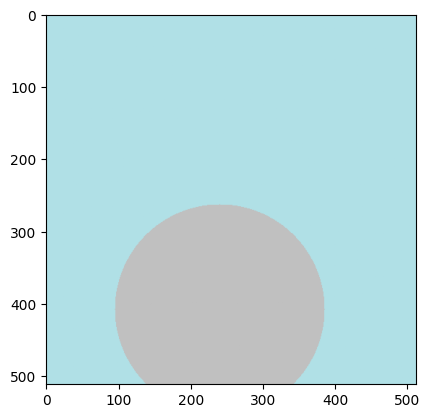

'silver circle with powder blue background'

In [12]:
import StableDiffusion.ControlnetFill50kDataSet
import StableDiffusion.Utils
import importlib
importlib.reload(StableDiffusion.ControlnetFill50kDataSet)
from StableDiffusion.ControlnetFill50kDataSet import ControlnetFill50kDataSet
from StableDiffusion.Utils import *

fill50kDataset = ControlnetFill50kDataSet()
i = 10
imgTensor,controlHint ,promptTokens ,attentionMask = fill50kDataset[i]
print(imgTensor.shape)
print(controlHint.shape)
print(promptTokens.shape)
print(attentionMask.shape )
Utils.showBatchImage(imgTensor[None,...])
fill50kDataset.promptList[i]


In [1]:
import json
import os

# Define the filename
fill50Path = '/home/aistudio/models/fill50k'
jsonFile = os.path.join(fill50Path, 'prompt.json')

with open(jsonFile, 'r') as f:
    for line in f:
        # Load the JSON object from the current line
        data = json.loads(line.strip())
        
        # Extract the specific fields
        file_name = data['target'].split('/')[-1]  # Gets '0.png' from 'target/0.png'
        prompt_text = data['prompt']
        
        # Respond with the formatted string
        print(f"File: {file_name} | Prompt: {prompt_text}")

File: 0.png | Prompt: pale golden rod circle with old lace background
File: 1.png | Prompt: light coral circle with white background
File: 2.png | Prompt: aqua circle with light pink background
File: 3.png | Prompt: cornflower blue circle with light golden rod yellow background
File: 4.png | Prompt: light slate gray circle with blue background
File: 5.png | Prompt: light golden rod yellow circle with turquoise background
File: 6.png | Prompt: crimson circle with papaya whip background
File: 7.png | Prompt: aqua circle with slate blue background
File: 8.png | Prompt: dark magenta circle with cyan background
File: 9.png | Prompt: papaya whip circle with corn silk background
File: 10.png | Prompt: silver circle with powder blue background
File: 11.png | Prompt: dark orange circle with gray background
File: 12.png | Prompt: cornflower blue circle with ivory background
File: 13.png | Prompt: honey dew circle with fire brick background
File: 14.png | Prompt: beige circle with yellow green ba